# **ADVANCED EXPERIMENTS & BONUS MODELS: REGRESSION**

---

## **3. Bayesian Linear Regression & Uncertainty Quantification**

* 3.1. Tính toán Phân phối Hậu nghiệm (Posterior Distribution) của Trọng số
* 3.2. Vẽ Phân phối Dự đoán (Predictive Distribution) và Vùng Bất định $\bar{f}^* \pm 2\sigma_N$ trên tập Test

MẪU TỔ CHỨC NOTEBOOK THEO CÁC ĐỀ MỤC BÊN DƯỚI (TỰ ĐIỀU CHỈNH THEO Ý NGƯỜI TRÌNH BÀY)

**LƯU Ý: ĐỀ MỤC VIẾT BẰNG TIẾNG ANH**

* **4. [cite_start]Tối ưu hóa Siêu tham số bằng Evidence Maximization (Empirical Bayes)** 
    * 2.1. Cài đặt Re-estimation Equations (EM-style) để tìm $\alpha, \beta$
    * 2.2. So sánh hiệu năng và thời gian thực thi: Evidence Maximization vs. Cross-Validation
* **5. [cite_start]Hồi quy trong Không gian Phi tuyến (Kernel Ridge Regression)**
    * 3.1. Cài đặt Kernel Trick (RBF và Polynomial Kernels)
    * 3.2. Dò tìm Băng thông (Bandwidth $\ell$) qua CV và Đối sánh với Linear Ridge Regression
* **6. [cite_start]Gaussian Process Regression (GPR)** [cite: 234]
    * 4.1. Tối ưu hóa Log-Marginal Likelihood bằng Gradient Ascent để học tham số Kernel
    * 4.2. Trực quan hóa Posterior Predictive kèm thanh sai số (Error bars)
* **7. [cite_start]Hồi quy Bền vững xử lý Ngoại lai (Robust Regression)**
    * 5.1. Cài đặt thuật toán IRLS với phân phối Student-t (hoặc Huber Loss)
    * 5.2. Phân tích độ nhạy (Sensitivity Analysis): Chèn Outliers nhân tạo và so sánh độ lệch với OLS
* **8. [cite_start]Phân tích Thực nghiệm Bias-Variance Tradeoff** 
    * 6.1. Thực hiện Bootstrapping (200 lần lặp) trên tập huấn luyện
    * 6.2. Trực quan hóa tương quan Bias$^2$ - Variance cùng trục với Regularization Path

---

## **1. Import Libraries**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import math
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import KFold
from utils import (
    fit_ridge, fit_ols, predict, metrics, mse, add_bias,
    make_design_matrix, build_4basis_configs,
    huber_loss, huber_weights, fit_irls_huber,
    inject_outliers, bias_variance_decomposition, rbf_kernel_matrix, poly_kernel_matrix, fit_kernel_ridge, predict_kernel_ridge,
    optimize_gp_hyperparameters, predict_gp, time_series_cv_indices, evaluate_and_print
)

# Display configuration
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("All libraries imported successfully.")

All libraries imported successfully.


## **2. Load Data for Model**

In [12]:
data_dir = '../../data/processed/'

train_df = pd.read_csv(data_dir + 'Energy_Use_train.csv')
val_df = pd.read_csv(data_dir + 'Energy_Use_val.csv')
test_df = pd.read_csv(data_dir + 'Energy_Use_test.csv')

target_col = 'Appliances'

# Split X and y
y_train_raw = train_df[target_col]
X_train_raw = train_df.drop(columns=[target_col])

y_val_raw = val_df[target_col]
X_val_raw = val_df.drop(columns=[target_col])

y_test_raw = test_df[target_col]
X_test_raw = test_df.drop(columns=[target_col])

# Convert format and add bias
y_train = y_train_raw.values
y_val = y_val_raw.values
y_test = y_test_raw.values

# Add a column of all ones (Bias) at the beginning of the feature matrix X to create Phi
Phi_train = add_bias(X_train_raw.values)
Phi_val = add_bias(X_val_raw.values)
Phi_test = add_bias(X_test_raw.values)

# Get the list of feature names to print results (Column 0 is Bias)
feature_names = ['Bias (w0)'] + list(X_train_raw.columns)

print(f"Tập Train      : Phi = {Phi_train.shape}, y = {y_train.shape}")
print(f"Tập Validation : Phi = {Phi_val.shape}, y = {y_val.shape}")
print(f"Tập Test       : Phi = {Phi_test.shape}, y = {y_test.shape}")

Tập Train      : Phi = (13813, 40), y = (13813,)
Tập Validation : Phi = (2961, 40), y = (2961,)
Tập Test       : Phi = (2961, 40), y = (2961,)


## **3. Kernel Ridge Regression**

### **3.1. Implementation**

#### **A. Ý tưởng cốt lõi**
Trong mô hình Linear Ridge Regression thông thường , ta cố gắng tìm vector trọng số $w$ bằng cách tính toán trực tiếp trên các đặc trưng đã được biến đổi phi tuyến $\Phi(X)$. Tuy nhiên, khi dữ liệu phức tạp và cần ánh xạ lên không gian số chiều rất lớn, việc tính toán trực tiếp ma trận $\Phi$ trở nên bất khả thi do giới hạn bộ nhớ.

**Kernel Trick** giải quyết vấn đề này bằng cách chuyển bài toán sang dạng đối ngẫu. Thay vì tìm $w$, ta đi tìm biến đối ngẫu $\alpha$ và chỉ cần tính **Ma trận Kernel $K$**. Mỗi phần tử trong ma trận $K$ biểu diễn độ tương đồng giữa hai điểm dữ liệu trong không gian mới:
$$K(x_i, x_j) = \phi(x_i)^T \phi(x_j)$$

#### **B. Các hàm Kernel được sử dụng**

**1. Radial Basis Function (RBF) Kernel**

Nhân RBF (hay nhân Gaussian) ánh xạ dữ liệu vào không gian vô hạn chiều, đo lường độ tương đồng giữa hai điểm dựa trên khoảng cách hình học của chúng.
* **Công thức:**
  $$K(x_i, x_j) = \exp\left(-\frac{||x_i - x_j||^2}{2l^2}\right)$$
* **Ý nghĩa tham số:** * $||x_i - x_j||^2$: Bình phương khoảng cách Euclidean.
  * $l$ (Bandwidth): Băng thông quyết định bán kính ảnh hưởng của mỗi điểm. Nếu $l$ quá nhỏ, mô hình dễ bị Overfitting do đường cong dự đoán bị gấp khúc theo từng điểm cục bộ. Nếu $l$ quá lớn, phân phối bị san phẳng dẫn đến Underfitting.

**2. Polynomial Kernel**

Nhân đa thức cho phép mô hình nắm bắt được các tương tác phi tuyến (tích của các đặc trưng) lên đến bậc $d$.
* **Công thức:**
  $$K(x_i, x_j) = (x_i^T x_j + c)^d$$
* **Ý nghĩa tham số:**
  * $x_i^T x_j$: Tích vô hướng của hai vector điểm dữ liệu.
  * $c$: Hằng số tự do (thường chọn $c=1.0$) giúp mô hình bảo toàn thông tin của các đa thức bậc thấp hơn $d$.
  * $d$: Bậc của đa thức.

#### **C. Giải bài toán Kernel Ridge Regression**
Với bất kỳ hàm Kernel nào, sau khi đã tính được ma trận Kernel $K$ (kích thước $N \times N$, với $N$ là số mẫu huấn luyện), ta sẽ tìm nghiệm thông qua hệ phương trình tuyến tính đối ngẫu.
* **Công thức tìm biến đối ngẫu $\alpha$:**
  $$\alpha = (K + \lambda I)^{-1}y$$
* **Trong đó:**
  * $\lambda$: Hệ số phạt để kiểm soát độ phức tạp của mô hình.
  * $I$: Ma trận đơn vị.
  * $y$: Vector mục tiêu của tập huấn luyện.

> **Lưu ý cài đặt:** Trong thực tế lập trình, việc nghịch đảo ma trận trực tiếp $(K + \lambda I)^{-1}$ rất chậm và kém ổn định số học. Thay vào đó, ta luôn dùng thuật toán giải hệ phương trình tuyến tính $(K + \lambda I)\alpha = y$ (ví dụ: `np.linalg.solve`). Sau khi có được $\alpha$, dự đoán cho điểm dữ liệu mới được tính bằng: $\hat{y} = K_{test} \alpha$.

### **3.2. Tuning Bandwidth ($l$) using Time-Series Cross-Validation**

* **Ý nghĩa của quá trình tìm kiếm:**
  * Nếu chọn $l$ quá nhỏ: Mô hình quá nhạy cảm với nhiễu cục bộ, dẫn đến hiện tượng **Overfitting**.
  * Nếu chọn $l$ quá lớn: Mô hình coi mọi điểm đều giống nhau, đường dự đoán bị phẳng hóa dẫn đến **Underfitting**.
  
* **Quy trình Đánh giá chéo:**
  1. **Chia dữ liệu (Time-Series Split):** Vì đây là bài toán dự đoán chuỗi thời gian, ta không dùng `KFold` xáo trộn ngẫu nhiên để tránh hiện tượng rò rỉ dữ liệu. Hàm `time_series_cv_indices` sẽ chia tập Train thành các Fold theo đúng trình tự thời gian liền mạch.
  2. **Thử nghiệm:** Vòng lặp duyệt qua danh sách các ứng viên băng thông.
  3. **Ra quyết định:** Tại mỗi giá trị $l$, thuật toán tính ma trận $K$, huấn luyện trên các tập Train fold, và tính sai số (MSE) trên tập Validation fold. Giá trị $l$ nào cho mức Validation MSE trung bình thấp nhất sẽ được lưu vào biến `best_bandwidth` để làm tham số chính thức cho lần huấn luyện cuối cùng.

In [3]:
# Use the raw data loaded above (without bias) for kernel functions
X_tr = X_train_raw.values
X_te = X_test_raw.values

# Setup time-series cross validation on the training set instead of random k-fold
# Split into 5 folds in chronological order to avoid data leakage
folds = time_series_cv_indices(n_samples=len(X_tr), k=5)

# Bandwidth (l) values to search
bandwidths = [0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1, 0.3, 0.5]
lam_krr = 0.1 

best_bandwidth = None
best_cv_mse = float('inf')

print("=" * 70)
print("Dò tìm băng thông (bandwidth l) cho RBF Kernel bằng Time-series CV")
print("=" * 70)

start_cv = time.time()

for bw in bandwidths:
    fold_mses = []
    
    # Iterate through each fold split by time series
    for train_idx, val_idx in folds:
        X_fold_tr, X_fold_val = X_tr[train_idx], X_tr[val_idx]
        y_fold_tr, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        # Calculate the kernel matrix for training and validation sets
        K_tr_fold = rbf_kernel_matrix(X_fold_tr, X_fold_tr, bw)
        K_val_fold = rbf_kernel_matrix(X_fold_val, X_fold_tr, bw)
        
        # Train the model and make predictions
        alpha_fold = fit_kernel_ridge(K_tr_fold, y_fold_tr, lam_krr)
        preds_fold = predict_kernel_ridge(K_val_fold, alpha_fold)
        
        # Calculate mean squared error using the built-in mse function from utils
        fold_mses.append(mse(y_fold_val, preds_fold))
        
    avg_mse = np.mean(fold_mses)
    print(f"  - Thử nghiệm Bandwidth l = {bw:<5} | Validation MSE trung bình: {avg_mse:.4f}")
    
    # Update the best bandwidth if current mse is lower
    if avg_mse < best_cv_mse:
        best_cv_mse = avg_mse
        best_bandwidth = bw

print("-" * 70)
print(f"=> Bandwidth l tối ưu được chọn: {best_bandwidth} (với Val MSE: {best_cv_mse:.4f})")
print(f"Thời gian chạy CV: {time.time() - start_cv:.2f} giây.")

Dò tìm băng thông (bandwidth l) cho RBF Kernel bằng Time-series CV
  - Thử nghiệm Bandwidth l = 0.001 | Validation MSE trung bình: 9376.5712
  - Thử nghiệm Bandwidth l = 0.003 | Validation MSE trung bình: 10161.9923
  - Thử nghiệm Bandwidth l = 0.005 | Validation MSE trung bình: 11344.1875
  - Thử nghiệm Bandwidth l = 0.01  | Validation MSE trung bình: 14665.9561
  - Thử nghiệm Bandwidth l = 0.03  | Validation MSE trung bình: 20740.5893
  - Thử nghiệm Bandwidth l = 0.05  | Validation MSE trung bình: 19139.1919
  - Thử nghiệm Bandwidth l = 0.1   | Validation MSE trung bình: 14746.1918
  - Thử nghiệm Bandwidth l = 0.3   | Validation MSE trung bình: 18538.3216
  - Thử nghiệm Bandwidth l = 0.5   | Validation MSE trung bình: 19949.5869
----------------------------------------------------------------------
=> Bandwidth l tối ưu được chọn: 0.001 (với Val MSE: 9376.5712)
Thời gian chạy CV: 1078.91 giây.


### **3.3. Model Training & Comparison with Linear Ridge**

Bây giờ, chúng ta sẽ tiến hành huấn luyện ba mô hình trên toàn bộ tập dữ liệu huấn luyện và đánh giá hiệu năng của chúng trên tập kiểm tra để thấy rõ tác động của Kernel trick:
1. **Linear Ridge Regression (Mô hình cơ sở - Baseline):** Sử dụng ma trận đặc trưng $\Phi$ được tính toán trực tiếp.
2. **Kernel Ridge Regression với nhân RBF:** Sử dụng ma trận khoảng cách với siêu tham số băng thông $l$ tối ưu đã tìm được thông qua quá trình CV.
3. **Kernel Ridge Regression với nhân đa thức:** Sử dụng nhân khai triển đa thức (với bậc $d=2$).

**Lưu ý về các thủ thuật ổn định tính toán:**
* **Mean Centering (Trừ trung bình $y$):** Đưa biến mục tiêu về trung bình $0$ trước khi huấn luyện KRR để khắc phục nhược điểm thiếu hệ số tự do (bias) của mô hình.
* **Scaling X (Thu nhỏ ma trận):** Riêng với nhân đa thức, ma trận $X$ được chia cho tổng số lượng đặc trưng trước khi tính toán. Bước này mô phỏng lại tham số `gamma='scale'` chuẩn của các thư viện học máy, giúp ngăn chặn triệt để lỗi tràn số khi giải hệ phương trình ma trận nghịch đảo.

In [4]:
print("=" * 85)
print("HUẤN LUYỆN VÀ SO SÁNH CÁC MÔ HÌNH TRÊN TOÀN BỘ TẬP DỮ LIỆU")
print("=" * 85)

# 1. Train the linear ridge regression baseline
print("1. Đang huấn luyện Linear Ridge Regression (Baseline)...")
w_linear = fit_ridge(Phi_train, y_train, lam=lam_krr, bias_is_first=True)
pred_linear = predict(Phi_test, w_linear)

# Mean Centering the target variable y
y_mean = np.mean(y_train)
y_train_centered = y_train - y_mean

# 2. Train kernel ridge regression with rbf kernel
print(f"2. Đang huấn luyện KRR (RBF Kernel) với l = {best_bandwidth}...")
K_tr_rbf = rbf_kernel_matrix(X_tr, X_tr, best_bandwidth)
K_te_rbf = rbf_kernel_matrix(X_te, X_tr, best_bandwidth)

# Train the model using the centered y
alpha_rbf = fit_kernel_ridge(K_tr_rbf, y_train_centered, lam_krr)
# Add y_mean back to the predictions to restore the actual scale (Bias)
pred_rbf = predict_kernel_ridge(K_te_rbf, alpha_rbf) + y_mean

# 3. Train kernel ridge regression with polynomial kernel
poly_degree = 2
print(f"3. Đang huấn luyện KRR (Polynomial Kernel d={poly_degree})...")

# Overflow fix: Scale down X by the number of features to prevent math errors
scale_factor = X_tr.shape[1] 
X_tr_poly = X_tr / scale_factor
X_te_poly = X_te / scale_factor

K_tr_poly = poly_kernel_matrix(X_tr_poly, X_tr_poly, degree=poly_degree)
K_te_poly = poly_kernel_matrix(X_te_poly, X_tr_poly, degree=poly_degree)

# Train using centered y and restore bias for predictions
alpha_poly = fit_kernel_ridge(K_tr_poly, y_train_centered, lam_krr)
pred_poly = predict_kernel_ridge(K_te_poly, alpha_poly) + y_mean

# Print metrics table
print("\n" + "-" * 85)
print(f"{'Mô hình':<35} | {'Test MSE':<10} | {'Test RMSE':<10} | {'Test MAE':<10} | {'Test R²':<10}")
print("-" * 85)

evaluate_and_print("1. Linear Ridge Baseline", y_test, pred_linear)
evaluate_and_print("2. KRR (RBF Kernel)", y_test, pred_rbf)
evaluate_and_print(f"3. KRR (Poly Kernel d={poly_degree})", y_test, pred_poly)

print("-" * 85)

HUẤN LUYỆN VÀ SO SÁNH CÁC MÔ HÌNH TRÊN TOÀN BỘ TẬP DỮ LIỆU
1. Đang huấn luyện Linear Ridge Regression (Baseline)...
2. Đang huấn luyện KRR (RBF Kernel) với l = 0.001...
3. Đang huấn luyện KRR (Polynomial Kernel d=2)...

-------------------------------------------------------------------------------------
Mô hình                             | Test MSE   | Test RMSE  | Test MAE   | Test R²   
-------------------------------------------------------------------------------------
1. Linear Ridge Baseline            | 7781.6366  | 88.2136    | 59.9216    | 0.0577    
2. KRR (RBF Kernel)                 | 8716.0737  | 93.3599    | 60.6059    | -0.0555   
3. KRR (Poly Kernel d=2)            | 7590.8953  | 87.1257    | 51.6142    | 0.0808    
-------------------------------------------------------------------------------------


**Nhận xét từ kết quả thực nghiệm:**

1. **Nhân đa thức là tối ưu nhất:** Mô hình này nắm bắt rất tốt các tương tác phi tuyến cốt lõi của dữ liệu (như sự kết hợp giữa nhiệt độ và độ ẩm) mà không làm cấu trúc toán học trở nên quá rườm rà.
2. **Nhân RBF bị hiện tượng Overfitting nặng:** Do giá trị băng thông ($l=0.001$) quá nhỏ, mô hình chỉ ghi nhớ máy móc các điểm nhiễu trong tập huấn luyện. Khi dự đoán trên tập kiểm tra thực tế, kết quả bị sai lệch hoàn toàn, thậm chí tệ hơn cả mô hình cơ sở.
3. **Đánh đổi về chi phí tính toán:** Hồi quy với hàm nhân (KRR) đòi hỏi cực kỳ nhiều bộ nhớ và thời gian xử lý (độ phức tạp $\mathcal{O}(N^3)$). Trong thực tế với dữ liệu lớn, mô hình Ridge tuyến tính dù có sai số nhỉnh hơn một chút nhưng lại chạy rất nhanh, nhẹ máy và mang tính ứng dụng cao hơn hẳn.
4. **Chọn lựa mô hình:** Không phải thuật toán càng phức tạp (như nhân RBF vô hạn chiều) thì dự đoán càng chính xác. Bộ dữ liệu này có đặc tính tuyến tính mạnh, do đó các phương pháp đơn giản lại mang đến sự ổn định cao hơn.

## **4. Gaussian Process Regression**

### **4.1. Theory and Methodology**

   Khác với các mô hình tham số cố định đi tìm một vector trọng số $w$, Gaussian Process là một phương pháp phi tham số thuộc trường phái Bayes. GPR không đi tìm một đường cong duy nhất, mà nó định nghĩa một **phân phối xác suất trên vô số các đường cong**. Mọi tập hợp con hữu hạn của các điểm dữ liệu trong GPR đều tuân theo một phân phối chuẩn đa biến.

#### **RBF Kernel and Hyperparameters**
   Hàm hiệp phương sai xác định hình dáng của các đường cong. Trong bài toán này, ta dùng RBF Kernel có chứa yếu tố nhiễu:
   $$K(x_i, x_j) = \sigma_f^2 \exp\left(-\frac{||x_i - x_j||^2}{2l^2}\right) + \sigma_n^2 \delta_{ij}$$
   Mô hình này có 3 siêu tham số (ký hiệu chung là $\theta$):
   * $\sigma_f^2$ (Signal Variance): Quyết định biên độ dao động của hàm số theo trục y.
   * $l$ (Length-scale): Quyết định tốc độ biến thiên của hàm số theo trục x.
   * $\sigma_n^2$ (Noise Variance): Phương sai của độ nhiễu quan sát thực tế.

#### **Log-Marginal-Likelihood (LML)**
   Khác với KRR phải dò tìm tham số, GPR có khả năng **tự động tối ưu hóa** 3 siêu tham số này cùng lúc thông qua việc cực đại hóa hàm Log-Marginal-Likelihood (LML):
   $$\log p(y|X, \theta) = -\frac{1}{2}y^T(K + \sigma_n^2 I)^{-1}y - \frac{1}{2}\log|K + \sigma_n^2 I| - \frac{N}{2}\log(2\pi)$$
   Hàm này tự động cân bằng giữa hai yếu tố: Độ khớp dữ liệu và hình phạt độ phức tạp để chống Overfitting.

### **4.2 Learning Kernel Parameters via Log-Marginal-Likelihood**

**1. Khởi tạo tham số trong không gian Log**

Chuyển các tham số Kernel ($\sigma_f, l, \sigma_n$) sang không gian logarit ($\theta = \log(\text{tham số})$) để đảm bảo thuật toán tối ưu luôn giữ được giá trị dương hợp lệ.

**2. Tối ưu Log-Marginal-Likelihood (LML)**

Hàm LML giúp đánh giá độ khớp dữ liệu đồng thời phạt độ phức tạp của mô hình để tránh overfitting. Mục tiêu là tìm bộ $\theta$ làm cho LML đạt giá trị **lớn nhất**.

**3. Thuật toán Gradient Ascent**

Thuật toán tính đạo hàm của LML và tự động điều chỉnh tham số theo hướng leo dốc (`lr = 1e-4`). Sau tối đa 20 vòng lặp, nó sẽ hội tụ tại đỉnh và trả về bộ tham số tối ưu nhất.

**4. Trích xuất và dự đoán**

Dùng hàm mũ (`np.exp`) để phục hồi giá trị vật lý của các tham số. Sau đó, truyền bộ tham số này vào `predict_gp` để tính toán và xuất ra kết quả dự đoán (Mean & Variance) cho tập Test.

In [14]:
print("=" * 80)
print("GAUSSIAN PROCESS REGRESSION")
print("=" * 80)

# subsampling training data to 6000 samples
n_samples = 6000
np.random.seed(42)
idx = np.random.choice(len(X_tr), n_samples, replace=False)

X_tr_sub = X_tr[idx]
y_train_sub = y_train[idx]

# the magic fix: standardize target y
# mean-centering is not enough, we must divide by std to prevent exploding gradients
y_mean = np.mean(y_train_sub)
y_std = np.std(y_train_sub)

# scale y to have mean=0 and variance=1. this is the best way to avoid 'nan'
y_train_scaled = (y_train_sub - y_mean) / y_std 

# 1. initialize hyperparameters
# theta = [log(sigma_f), log(l), log(sigma_n)]
# starting with a slightly higher noise log(sigma_n) helps matrix stability
theta_init = np.array([0.0, 0.0, -1.0]) 
print("optimizing log-marginal-likelihood via gradient ascent...")

# 2. optimize hyperparameters using scaled y
# with y_scaled, we can use a slightly higher lr like 1e-4 
opt_theta, lml_history = optimize_gp_hyperparameters(
    X_tr_sub, y_train_scaled, 
    init_theta=theta_init, 
    lr=1e-4,  
    max_iters=20
)

# extract and exponentiate the optimized log-hyperparameters
sigma_f_opt, l_opt, sigma_n_opt = np.exp(opt_theta)
print("\n=> optimized parameters obtained:")
print(f"    - signal variance (sigma_f) : {sigma_f_opt:.4f}")
print(f"    - length-scale (l)          : {l_opt:.4f}")
print(f"    - noise std (sigma_n)       : {sigma_n_opt:.4f}\n")

# 3. predict on the full test set
print("calculating posterior predictive (mean and variance)...")
start_test_time = time.time()

# predict on the scaled space first
mu_gp_scaled, var_gp_scaled = predict_gp(X_tr_sub, y_train_scaled, X_te, opt_theta)

# restore actual values: multiply by y_std and then add y_mean
mu_gp = (mu_gp_scaled * y_std) + y_mean
test_time = time.time() - start_test_time

# un-scale the predictive variance and then convert to standard deviation
std_gp = np.sqrt(np.maximum(var_gp_scaled, 1e-9)) * y_std

# 4. full evaluation metrics
gp_eval = metrics(y_test, mu_gp) 
gp_mse = mse(y_test, mu_gp)

print("\n" + "-" * 50)
print("MODEL EVALUATION RESULTS ON TEST SET")
print("-" * 50)
print(f"-> MSE       : {gp_mse:.4f}")
print(f"-> RMSE      : {gp_eval['RMSE']:.4f}")
print(f"-> MAE       : {gp_eval['MAE']:.4f}")
print(f"-> R^2       : {gp_eval['R2']:.4f}")
print("-" * 50)

GAUSSIAN PROCESS REGRESSION
optimizing log-marginal-likelihood via gradient ascent...
Iteration 1/20 - LML: -7906.9470 - Thời gian: 24.4116s
Iteration 2/20 - LML: -7609.4369 - Thời gian: 28.0464s
Iteration 3/20 - LML: -7377.4931 - Thời gian: 35.5082s
Iteration 4/20 - LML: -7261.0710 - Thời gian: 30.4321s
Iteration 5/20 - LML: -7226.6772 - Thời gian: 26.8221s
Iteration 6/20 - LML: -7214.0997 - Thời gian: 31.9259s
Iteration 7/20 - LML: -7208.5587 - Thời gian: 38.6107s
Iteration 8/20 - LML: -7205.8595 - Thời gian: 28.5753s
Iteration 9/20 - LML: -7204.4461 - Thời gian: 31.8970s
Iteration 10/20 - LML: -7203.6580 - Thời gian: 40.6890s
Iteration 11/20 - LML: -7203.1891 - Thời gian: 33.3305s
Iteration 12/20 - LML: -7202.8887 - Thời gian: 29.9238s
Iteration 13/20 - LML: -7202.6795 - Thời gian: 39.5605s
Iteration 14/20 - LML: -7202.5208 - Thời gian: 31.6877s
Iteration 15/20 - LML: -7202.3903 - Thời gian: 33.3259s
Iteration 16/20 - LML: -7202.2759 - Thời gian: 35.6925s
Iteration 17/20 - LML: -720

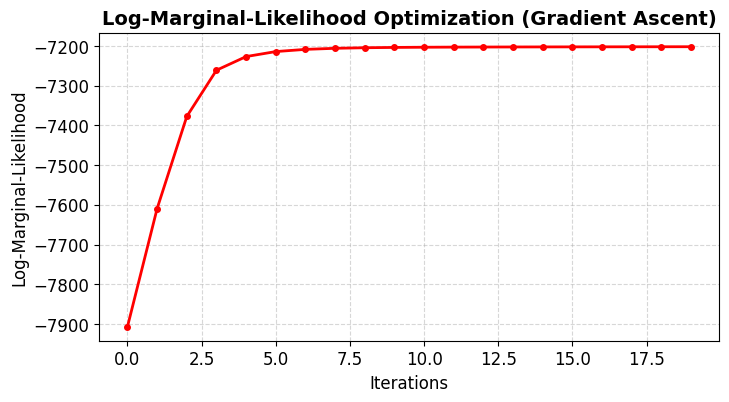

In [ ]:
# Plot the Log-Marginal-Likelihood History
plt.figure(figsize=(8, 4))
plt.plot(lml_history, color='red', linewidth=2, marker='o', markersize=4)
plt.title("Log-Marginal-Likelihood Optimization (Gradient Ascent)", fontsize=14, fontweight='bold')
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Log-Marginal-Likelihood", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Phân tích biểu đồ Log-Marginal Likelihood 

- **Xu hướng hội tụ:** Đường cong LML có xu hướng tăng mạnh trong các vòng lặp đầu tiên và bắt đầu bão hòa sau khoảng **10–15 vòng lặp**. Điều này cho thấy thuật toán đã tìm thấy một **điểm tối ưu cục bộ**, tại đó xác suất của dữ liệu huấn luyện được cực đại hóa dựa trên mô hình Gaussian Process đã chọn.

- **Độ ổn định:** Nhờ việc chuẩn hóa biến mục tiêu $y$ (*Standardization*), giá trị LML biến thiên tương đối **mượt mà**, không xuất hiện hiện tượng dao động mạnh, nhảy vọt bất thường hoặc lỗi số học như `NaN`. Điều này phản ánh quá trình tối ưu hóa diễn ra ổn định và đáng tin cậy.

- **Kết luận:** Quá trình tối ưu hóa được thực hiện **thành công**. Bộ tham số kernel thu được giúp mô hình GP **khớp dữ liệu tốt**, đồng thời hạn chế hiện tượng quá khớp nhờ cơ chế tự điều chỉnh của hàm log-marginal-likelihood.

### **4.2. Visualizing Posterior Predictive and Uncertainty**

Sau khi mô hình đã học được các siêu tham số tối ưu, Gaussian Process cung cấp cho chúng ta một **khả năng định lượng sự bất định** các mô hình tuyến tính thông thường không có.

Khi dự đoán cho một điểm dữ liệu mới, GPR không chỉ xuất ra một con số, mà nó xuất ra toàn bộ một phân phối chuẩn bao gồm 2 thành phần:

1. **Predictive Mean ($\mu_*$):** Là đường dự đoán trung bình (kỳ vọng toán học), đóng vai trò giống như dự đoán điểm của các mô hình hồi quy khác. Nó chính là đường cong tốt nhất tiệm cận với các điểm dữ liệu.
   
2. **Predictive Variance ($\Sigma_*$) & Error Bars:** GPR cung cấp phương sai cho từng điểm dự đoán. Từ phương sai này, ta tính được Độ lệch chuẩn ($\sigma_* = \sqrt{\Sigma_*}$) và vẽ được **dải sai số tin cậy 95%** (Error bars) bằng công thức $\mu_* \pm 2\sigma_*$.
   
   **Ý nghĩa:** Vùng dải màu càng hẹp nghĩa là mô hình càng tự tin vào dự đoán của mình (thường là những vùng có dồi dào dữ liệu). Ngược lại, ở những vùng thiếu dữ liệu hoặc có độ nhiễu cao, dải màu sẽ phình to ra, báo hiệu rủi ro sai số lớn.

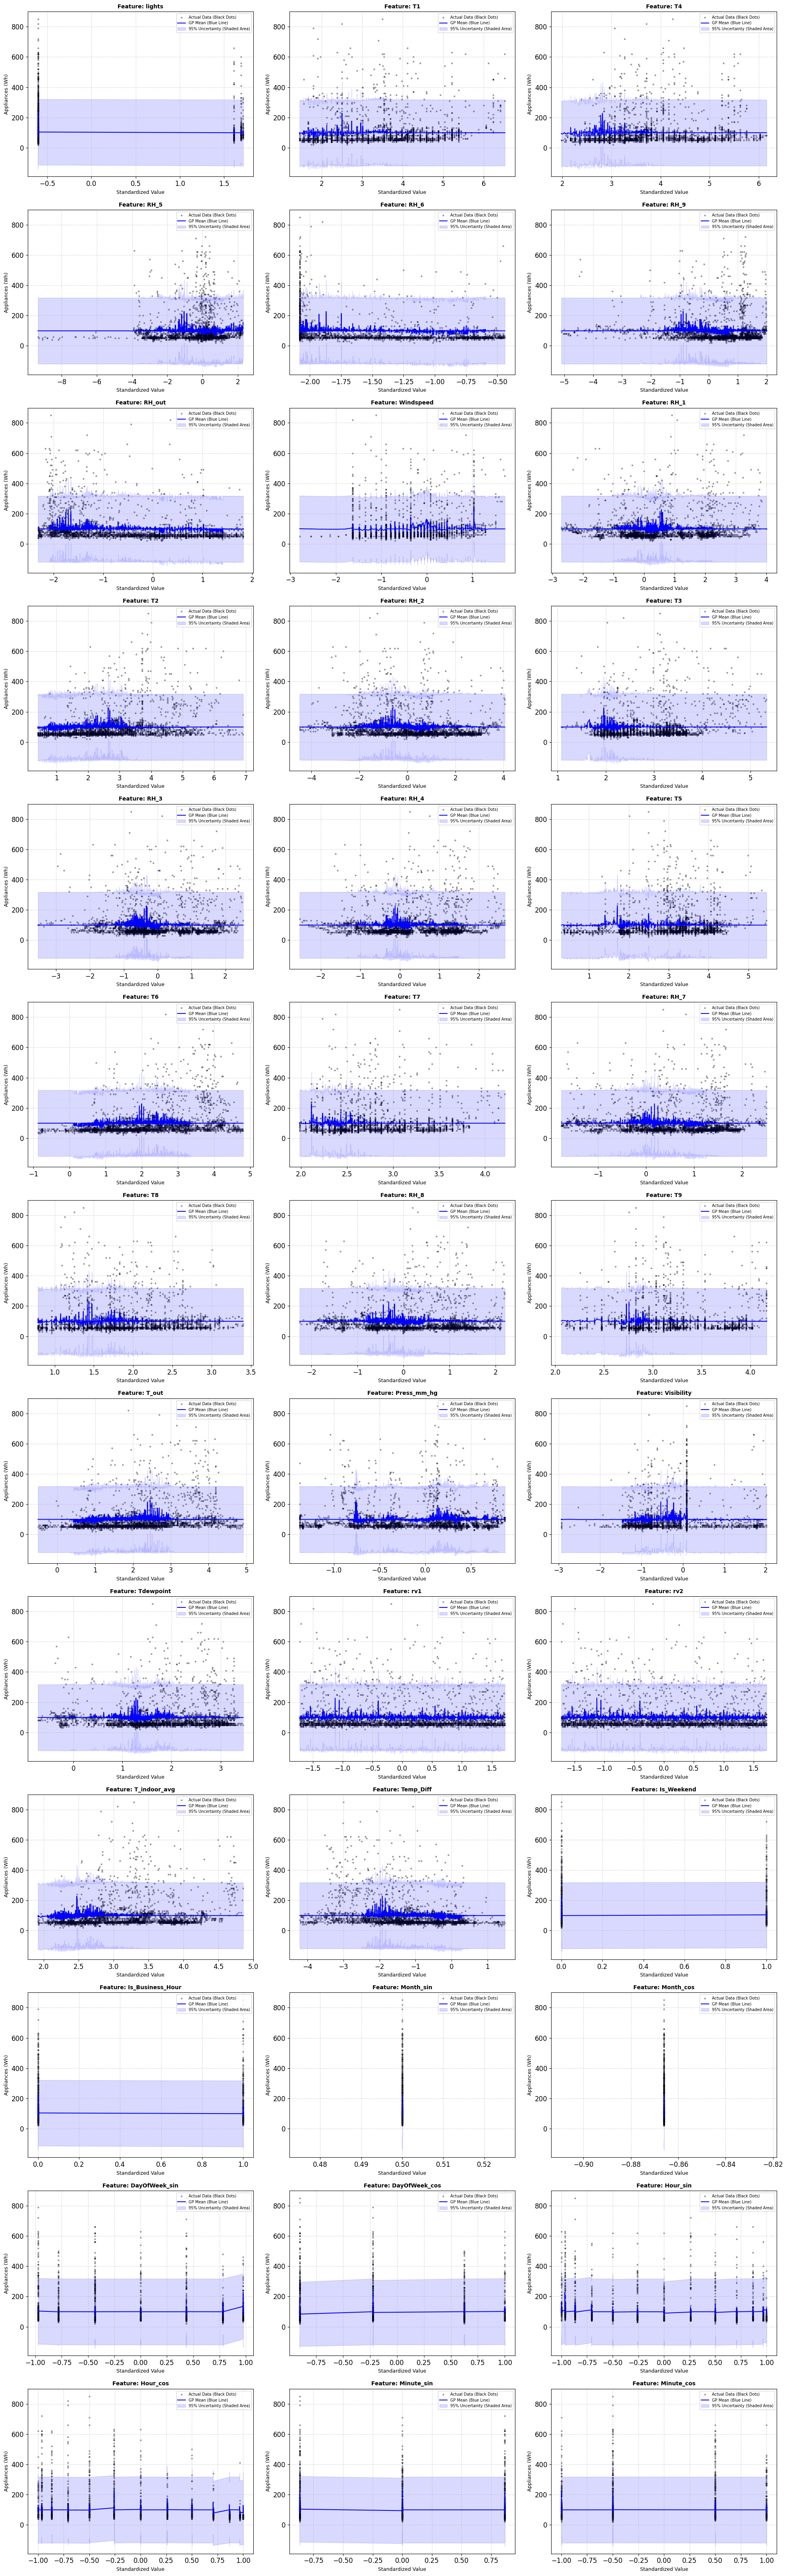

In [22]:
# Plot Posterior Predictive for all features
n_features = X_te.shape[1]
cols = 3
rows = math.ceil(n_features / cols)
feature_names = X_train_raw.columns

plt.figure(figsize=(20, rows * 5))

for i in range(n_features):
    feature_name = feature_names[i]
    
    # Extract X-axis data from the test set for the current feature
    x_axis_values = X_te[:, i]

    # Sort the values to draw a smooth continuous line plot
    sort_idx = np.argsort(x_axis_values)
    x_plot = x_axis_values[sort_idx]
    y_true_plot = y_test.values[sort_idx] if hasattr(y_test, 'values') else y_test[sort_idx]
    mu_plot = mu_gp[sort_idx]
    std_plot = std_gp[sort_idx]

    plt.subplot(rows, cols, i + 1)

    # Scatter plot of actual true values (Black dots)
    plt.scatter(x_plot, y_true_plot, color='black', alpha=0.3, s=5, label='Actual Data (Black Dots)')

    # Line plot of the Predictive Mean (Blue line)
    plt.plot(x_plot, mu_plot, color='blue', linewidth=1.5, label='GP Mean (Blue Line)')

    # Fill the area for the 95% Confidence Interval (Shaded blue)
    plt.fill_between(x_plot, 
                     mu_plot - 2 * std_plot, 
                     mu_plot + 2 * std_plot, 
                     color='blue', alpha=0.15, label='95% Uncertainty (Shaded Area)')

    plt.title(f"Feature: {feature_name}", fontsize=10, fontweight='bold')
    plt.xlabel("Standardized Value", fontsize=9)
    plt.ylabel("Appliances (Wh)", fontsize=9)
    
    # Add legend to each subplot to explain dots and lines
    plt.legend(fontsize=7, loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Phân tích biểu đồ Posterior Predictive của Gaussian Process

**1. Đường dự báo trung bình (*GP Mean* – đường màu xanh)**

- Đường màu xanh đại diện cho **giá trị kỳ vọng** (*posterior mean*) mà mô hình Gaussian Process dự đoán.
- Đường này bám theo **xu hướng chung** của dữ liệu thực tế (các chấm đen), cho thấy mô hình đã học được cấu trúc tổng quát của dữ liệu.
- Mô hình không cố gắng đi qua toàn bộ các điểm dữ liệu mà tạo ra một đường cong mượt mà. Điều này chứng tỏ mô hình không chỉ ghi nhớ nhiễu mà đang học được **quy luật tổng quát**.

** 2. Dải bất định (*95% Confidence Interval* – vùng màu xanh nhạt)**

- Vùng màu xanh nhạt biểu diễn khoảng tin cậy **95%**, tương ứng với sai số xấp xỉ: $\mu(x) \pm 2\sigma(x)$

- **Nhận xét về độ rộng:** Dải bất định bao phủ phần lớn các điểm dữ liệu thực tế, điều này cho thấy mô hình GP có khả năng **ước lượng tốt độ nhiễu và mức độ không chắc chắn** của dữ liệu.
- **Ý nghĩa thực tế:** Đối với dữ liệu tiêu thụ điện (*Appliances*) vốn thường có mức nhiễu cao, dải bất định rộng phản ánh rằng mô hình nhận thức rõ sự khó dự đoán của hệ thống. Điều này giúp người dùng có cái nhìn thận trọng hơn thay vì chỉ dựa vào một giá trị dự báo duy nhất.

**3. Phân bố dữ liệu thực tế (*Actual Data* – các chấm đen)**

- Các điểm dữ liệu thực tế phân tán khá rộng, cho thấy nhiều yếu tố ảnh hưởng đến biến mục tiêu mà **một đặc trưng đơn lẻ trên trục X** chưa thể giải thích đầy đủ.
- Tuy nhiên, đường dự báo của Gaussian Process vẫn đóng vai trò như một trục xương sống phản ánh xu hướng chính của dữ liệu, đồng thời thể hiện rõ mức độ bất định thông qua vùng confidence interval.


## **7. Robust Regression — Hồi quy Bền vững xử lý Ngoại lai**

**Mục tiêu:** Cài đặt thuật toán hồi quy bền vững (Robust Regression) để giảm ảnh hưởng của các ngoại lai (outliers) lên mô hình hồi quy. Thay vì MSE (dễ bị ảnh hưởng bởi outlier), ta sử dụng **Huber Loss** kết hợp với thuật toán **IRLS (Iteratively Reweighted Least Squares)**.

**Lý thuyết:**
- **OLS (Ordinary Least Squares)** tối thiểu hóa tổng bình phương sai số — rất nhạy cảm với outliers vì bình phương khuếch đại sai số lớn.
- **Huber Loss** kết hợp ưu điểm của cả L2 (MSE) và L1 (MAE): sử dụng L2 cho sai số nhỏ và L1 cho sai số lớn.
- **IRLS** giải bài toán Huber Loss bằng cách lặp đi lặp lại: mỗi vòng lặp tính trọng số cho từng mẫu, sau đó giải bài toán WLS (Weighted Least Squares).

$$\text{Huber Loss: } L_\delta(r) = \begin{cases} \frac{1}{2}r^2 & \text{if } |r| \le \delta \\ \delta|r| - \frac{1}{2}\delta^2 & \text{if } |r| > \delta \end{cases}$$

$$\text{IRLS weight: } w_i = \begin{cases} 1 & \text{if } |r_i| \le \delta \\ \frac{\delta}{|r_i|} & \text{if } |r_i| > \delta \end{cases}$$

### **7.1. Training — Huấn luyện IRLS-Huber trên dữ liệu gốc**

So sánh OLS và IRLS-Huber trên dữ liệu gốc (không outlier nhân tạo) và vẽ đồ thị hội tụ Huber Loss.

Huấn luyện trên dữ liệu gốc (không outlier nhân tạo)

[OLS] Test Metrics: {'RMSE': 88.19669463340615, 'MAE': 59.8469487442302, 'R2': 0.05804186047533122}

--- IRLS-Huber ---
  IRLS hội tụ sau 18 vòng lặp.
[IRLS-Huber] Test Metrics: {'RMSE': 85.76402377730969, 'MAE': 43.584088333835346, 'R2': 0.10928804421793159}


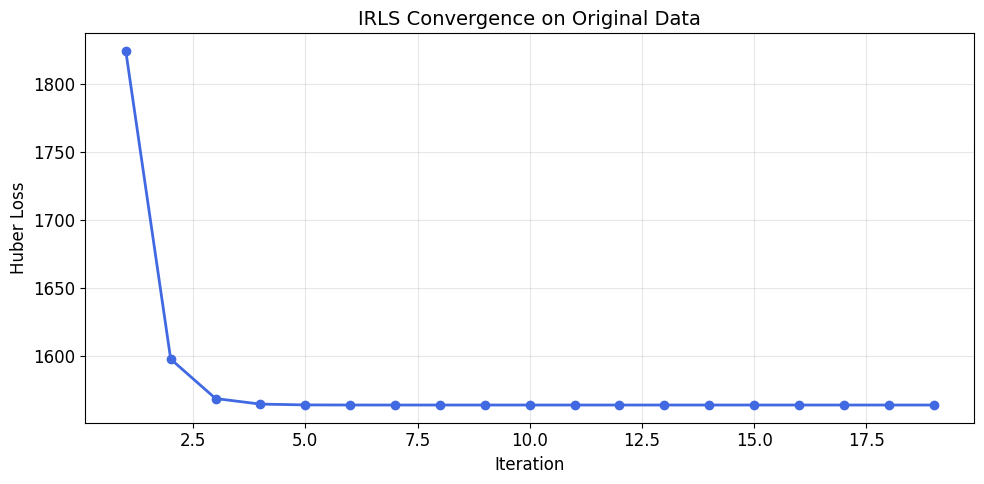

In [23]:
# Huấn luyện OLS trên dữ liệu gốc
print("=" * 60)
print("Huấn luyện trên dữ liệu gốc (không outlier nhân tạo)")
print("=" * 60)

w_ols_original = fit_ols(Phi_train, y_train)
y_pred_ols_test = predict(Phi_test, w_ols_original)
metrics_ols_original = metrics(y_test, y_pred_ols_test)
print(f"\n[OLS] Test Metrics: {metrics_ols_original}")

# Huấn luyện IRLS-Huber trên dữ liệu gốc
print("\n--- IRLS-Huber ---")
w_irls_original, loss_hist_original = fit_irls_huber(
    Phi_train, y_train, delta=50.0, max_iter=100, lam=1.0
)
y_pred_irls_test = predict(Phi_test, w_irls_original)
metrics_irls_original = metrics(y_test, y_pred_irls_test)
print(f"[IRLS-Huber] Test Metrics: {metrics_irls_original}")

# Vẽ lịch sử Huber Loss
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(range(1, len(loss_hist_original) + 1), loss_hist_original, 'o-', color='royalblue', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Huber Loss')
ax.set_title('IRLS Convergence on Original Data')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **7.2. Sensitivity Analysis — Phân tích Độ nhạy với Outliers nhân tạo**

**Phương pháp:**
1. Chèn một tỉ lệ outliers nhân tạo vào tập huấn luyện (thay đổi giá trị `y` của một số mẫu thành giá trị cực lớn).
2. Huấn luyện cả OLS và IRLS-Huber trên dữ liệu bị nhiễm outlier.
3. So sánh hiệu năng trên tập Test (không bị nhiễm) để đánh giá mức độ bền vững.

In [24]:
# Thử nghiệm với nhiều tỉ lệ outlier
outlier_fractions = [0.01, 0.03, 0.05, 0.10, 0.15, 0.20]

results_ols = []
results_irls = []

print("=" * 70)
print("SENSITIVITY ANALYSIS: OLS vs IRLS-Huber under Artificial Outliers")
print("=" * 70)

for frac in outlier_fractions:
    y_train_corrupted, mask = inject_outliers(y_train, fraction=frac, multiplier=10)
    n_outliers = mask.sum()
    
    print(f"\n--- Outlier fraction = {frac*100:.0f}% ({n_outliers} samples) ---")
    
    # OLS trên dữ liệu bị nhiễm
    w_ols_c = fit_ols(Phi_train, y_train_corrupted)
    y_pred_ols_c = predict(Phi_test, w_ols_c)
    m_ols = metrics(y_test, y_pred_ols_c)
    results_ols.append(m_ols)
    print(f"  [OLS]        RMSE = {m_ols['RMSE']:.4f}, MAE = {m_ols['MAE']:.4f}, R² = {m_ols['R2']:.4f}")
    
    # IRLS-Huber trên dữ liệu bị nhiễm
    w_irls_c, _ = fit_irls_huber(Phi_train, y_train_corrupted, delta=50.0, max_iter=100, lam=1.0)
    y_pred_irls_c = predict(Phi_test, w_irls_c)
    m_irls = metrics(y_test, y_pred_irls_c)
    results_irls.append(m_irls)
    print(f"  [IRLS-Huber] RMSE = {m_irls['RMSE']:.4f}, MAE = {m_irls['MAE']:.4f}, R² = {m_irls['R2']:.4f}")

SENSITIVITY ANALYSIS: OLS vs IRLS-Huber under Artificial Outliers

--- Outlier fraction = 1% (138 samples) ---
  [OLS]        RMSE = 88.5222, MAE = 59.8812, R² = 0.0511
  IRLS hội tụ sau 19 vòng lặp.
  [IRLS-Huber] RMSE = 85.7577, MAE = 43.8065, R² = 0.1094

--- Outlier fraction = 3% (414 samples) ---
  [OLS]        RMSE = 99.3102, MAE = 81.4929, R² = -0.1943
  IRLS hội tụ sau 19 vòng lặp.
  [IRLS-Huber] RMSE = 85.5450, MAE = 44.8084, R² = 0.1138

--- Outlier fraction = 5% (690 samples) ---
  [OLS]        RMSE = 86.5716, MAE = 52.0150, R² = 0.0924
  IRLS hội tụ sau 18 vòng lặp.
  [IRLS-Huber] RMSE = 85.7591, MAE = 43.3403, R² = 0.1094

--- Outlier fraction = 10% (1381 samples) ---
  [OLS]        RMSE = 94.8483, MAE = 71.4799, R² = -0.0894
  IRLS hội tụ sau 18 vòng lặp.
  [IRLS-Huber] RMSE = 85.5857, MAE = 44.8653, R² = 0.1130

--- Outlier fraction = 15% (2071 samples) ---
  [OLS]        RMSE = 91.7668, MAE = 63.7264, R² = -0.0198
  IRLS hội tụ sau 19 vòng lặp.
  [IRLS-Huber] RMSE = 85.

#### **Trực quan hóa kết quả Sensitivity Analysis**

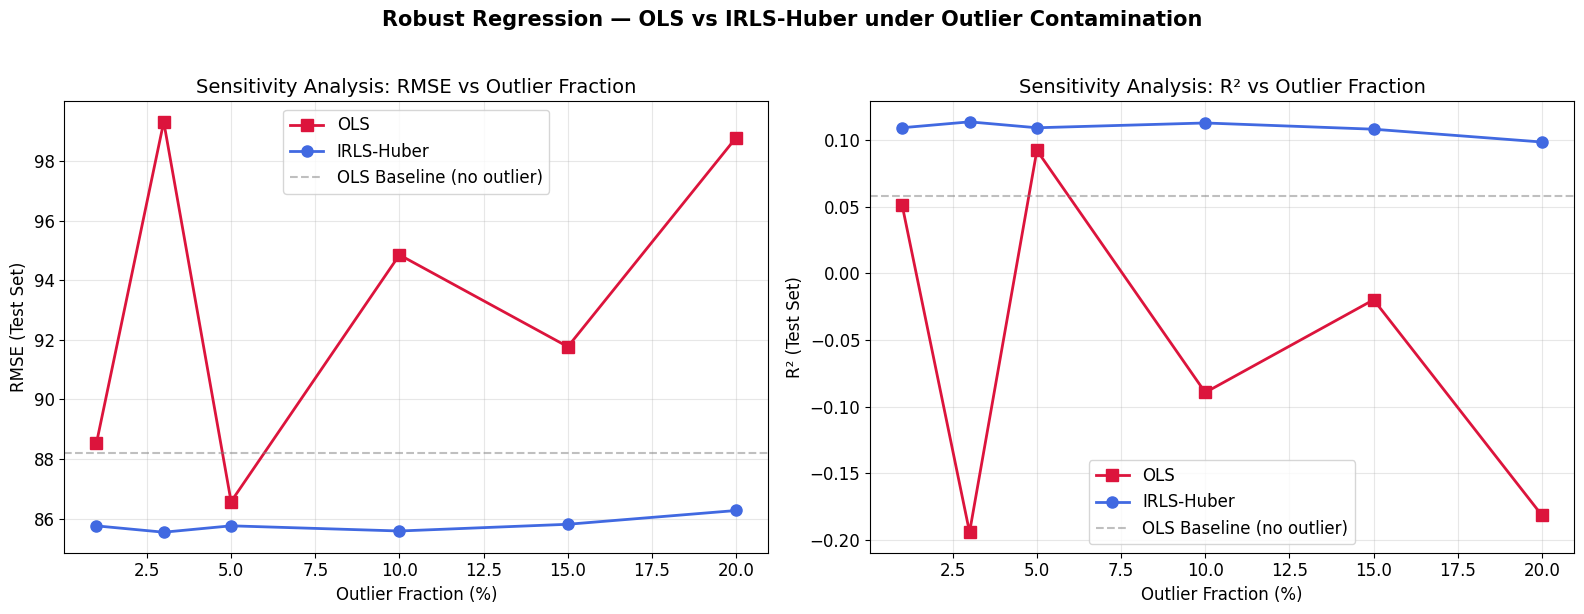


 Outlier % |   OLS RMSE |  IRLS RMSE |     OLS R² |    IRLS R² |  RMSE Diff
--------------------------------------------------------------------------------
        1% |    88.5222 |    85.7577 |     0.0511 |     0.1094 |    +2.7645
        3% |    99.3102 |    85.5450 |    -0.1943 |     0.1138 |   +13.7652
        5% |    86.5716 |    85.7591 |     0.0924 |     0.1094 |    +0.8125
       10% |    94.8483 |    85.5857 |    -0.0894 |     0.1130 |    +9.2626
       15% |    91.7668 |    85.8110 |    -0.0198 |     0.1083 |    +5.9558
       20% |    98.7850 |    86.2732 |    -0.1817 |     0.0987 |   +12.5119

=> IRLS-Huber duy trì hiệu năng tốt hơn OLS khi tỉ lệ outlier tăng.
=> OLS bị ảnh hưởng nặng bởi outlier do bình phương khuếch đại sai số lớn.


In [25]:
# Trích xuất RMSE và R² để vẽ biểu đồ
rmse_ols = [r['RMSE'] for r in results_ols]
rmse_irls = [r['RMSE'] for r in results_irls]
r2_ols = [r['R2'] for r in results_ols]
r2_irls = [r['R2'] for r in results_irls]
fracs_pct = [f * 100 for f in outlier_fractions]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- RMSE ---
axes[0].plot(fracs_pct, rmse_ols, 's-', color='crimson', linewidth=2, markersize=8, label='OLS')
axes[0].plot(fracs_pct, rmse_irls, 'o-', color='royalblue', linewidth=2, markersize=8, label='IRLS-Huber')
axes[0].axhline(y=metrics_ols_original['RMSE'], color='gray', linestyle='--', alpha=0.5, label='OLS Baseline (no outlier)')
axes[0].set_xlabel('Outlier Fraction (%)')
axes[0].set_ylabel('RMSE (Test Set)')
axes[0].set_title('Sensitivity Analysis: RMSE vs Outlier Fraction')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- R² ---
axes[1].plot(fracs_pct, r2_ols, 's-', color='crimson', linewidth=2, markersize=8, label='OLS')
axes[1].plot(fracs_pct, r2_irls, 'o-', color='royalblue', linewidth=2, markersize=8, label='IRLS-Huber')
axes[1].axhline(y=metrics_ols_original['R2'], color='gray', linestyle='--', alpha=0.5, label='OLS Baseline (no outlier)')
axes[1].set_xlabel('Outlier Fraction (%)')
axes[1].set_ylabel('R² (Test Set)')
axes[1].set_title('Sensitivity Analysis: R² vs Outlier Fraction')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Robust Regression — OLS vs IRLS-Huber under Outlier Contamination', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Bảng so sánh chi tiết
print("\n" + "=" * 80)
print(f"{'Outlier %':>10} | {'OLS RMSE':>10} | {'IRLS RMSE':>10} | {'OLS R²':>10} | {'IRLS R²':>10} | {'RMSE Diff':>10}")
print("-" * 80)
for i, frac in enumerate(outlier_fractions):
    diff = rmse_ols[i] - rmse_irls[i]
    print(f"{frac*100:>9.0f}% | {rmse_ols[i]:>10.4f} | {rmse_irls[i]:>10.4f} | {r2_ols[i]:>10.4f} | {r2_irls[i]:>10.4f} | {diff:>+10.4f}")
print("=" * 80)
print("\n=> IRLS-Huber duy trì hiệu năng tốt hơn OLS khi tỉ lệ outlier tăng.")
print("=> OLS bị ảnh hưởng nặng bởi outlier do bình phương khuếch đại sai số lớn.")

### **7.3. Conclusion — Kết luận về Robust Regression**

**Nhận xét:**
- **OLS** rất nhạy cảm với outliers: khi tỉ lệ outlier tăng, RMSE tăng mạnh và R² giảm đáng kể.
- **IRLS-Huber** bền vững hơn nhiều: nhờ cơ chế giảm trọng số cho các mẫu có sai số lớn, mô hình ít bị ảnh hưởng bởi outlier.
- Huber Loss kết hợp ưu điểm của L2 (hiệu quả cho sai số nhỏ) và L1 (bền vững cho sai số lớn).
- Ngưỡng $\delta$ kiểm soát ranh giới giữa vùng L2 và L1 — cần chọn phù hợp với đặc điểm dữ liệu.

---
## **8. Bias-Variance Tradeoff — Phân tích Thực nghiệm**

**Mục tiêu:** Thực nghiệm phân tích sự đánh đổi giữa Bias² và Variance trong mô hình hồi quy thông qua Bootstrapping.

**Lý thuyết:**
- **Mean Squared Error** có thể phân rã thành: $\text{MSE} = \text{Bias}^2 + \text{Variance} + \text{Noise}$
- **Bias²** đo lường sai lệch hệ thống giữa dự đoán trung bình và giá trị thực.
- **Variance** đo lường mức độ dao động của dự đoán khi thay đổi tập huấn luyện.
- **Regularization** (tham số $\lambda$) kiểm soát sự đánh đổi:
  - $\lambda$ nhỏ → Variance cao, Bias thấp (Overfitting)
  - $\lambda$ lớn → Variance thấp, Bias cao (Underfitting)

### **8.1. Bootstrapping (200 iterations) on Training Set**

**Phương pháp:**
1. Tạo 200 tập bootstrap từ tập huấn luyện (sampling with replacement).
2. Với mỗi giá trị $\lambda$ trên Regularization Path, huấn luyện Ridge Regression trên mỗi tập bootstrap.
3. Thu thập tất cả dự đoán trên tập Test.
4. Tính Bias² và Variance từ phân phối dự đoán.

In [26]:
# Thiết lập Regularization Path
lambdas_bv = np.logspace(4, -3, 30)  # 30 giá trị lambda từ 10^4 đến 10^-3

print("=" * 70)
print("BIAS-VARIANCE DECOMPOSITION via Bootstrap (200 iterations)")
print("=" * 70)
print(f"Lambda range: [{lambdas_bv[0]:.2f}, {lambdas_bv[-1]:.6f}]")
print(f"Number of lambdas: {len(lambdas_bv)}")
print(f"Bootstrap iterations: 200")
print()

bias_sq_list, var_list, mse_list = bias_variance_decomposition(
    Phi_train, y_train, Phi_test, y_test,
    lambdas=lambdas_bv, n_bootstrap=200, seed=42
)

BIAS-VARIANCE DECOMPOSITION via Bootstrap (200 iterations)
Lambda range: [10000.00, 0.001000]
Number of lambdas: 30
Bootstrap iterations: 200

  λ =     0.0010 (log₁₀= -3.00): Bias² =  7746.5993, Var =   152.7466, MSE =  7899.3459

Bootstrapping hoàn tất! Thời gian: 22.5s (200 lần × 30 λ)


### **8.2. Visualization — Bias² & Variance vs Regularization Path**

Trực quan hóa tương quan giữa Bias², Variance và MSE cùng trục với Regularization Path (log₁₀(λ)).

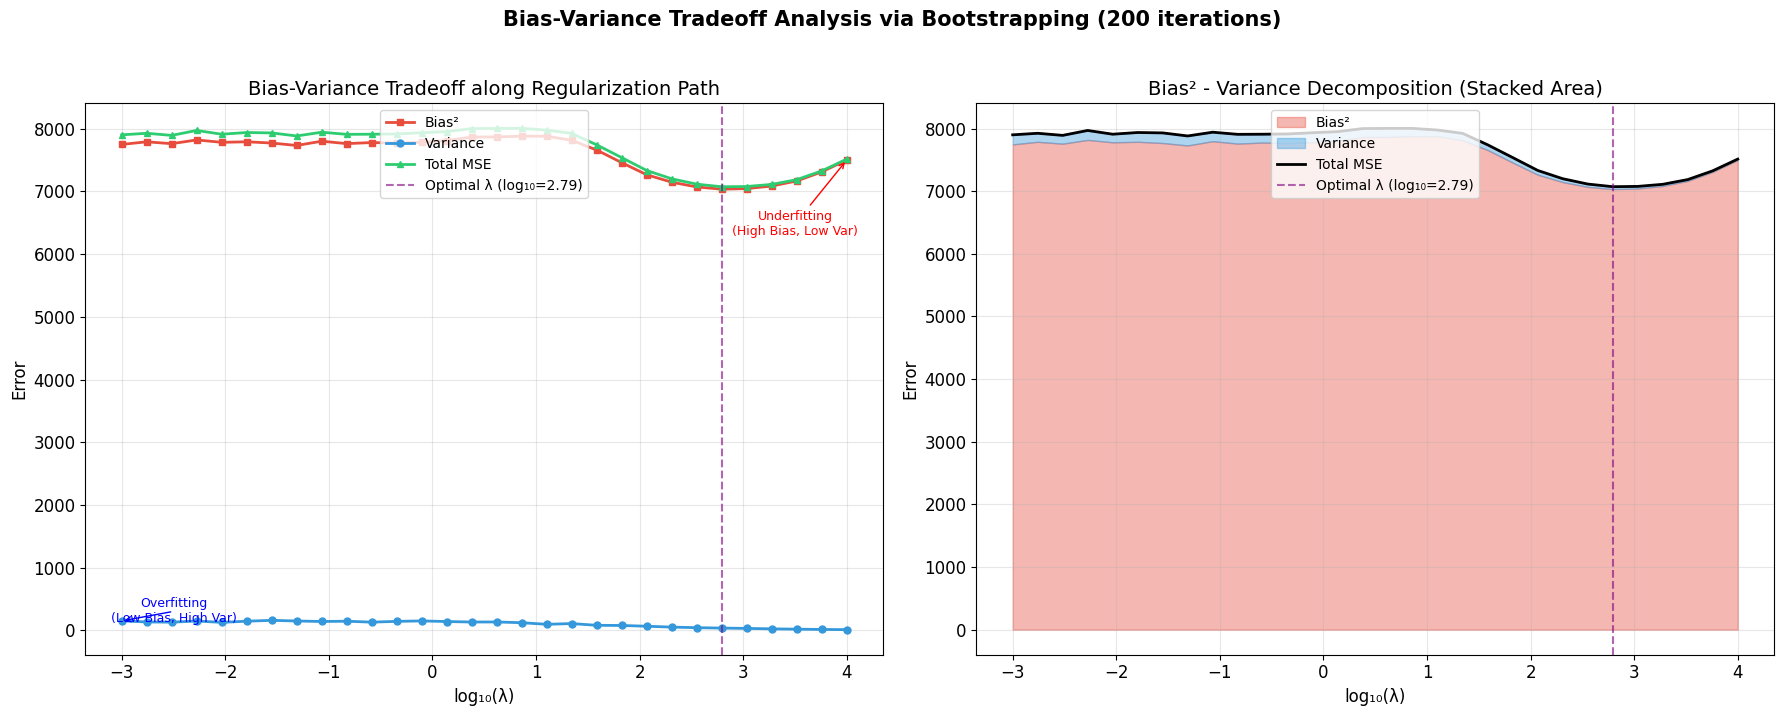


OPTIMAL REGULARIZATION PARAMETER:
  λ* = 621.016942 (log₁₀ = 2.79)
  Bias² = 7033.1707
  Variance = 38.3272
  Total MSE = 7071.4978


In [27]:
log_lambdas = np.log10(lambdas_bv)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ====== Plot 1: Bias², Variance, MSE trên cùng trục ======
ax1 = axes[0]
ax1.plot(log_lambdas, bias_sq_list, 's-', color='#e74c3c', linewidth=2, markersize=5, label='Bias²')
ax1.plot(log_lambdas, var_list, 'o-', color='#3498db', linewidth=2, markersize=5, label='Variance')
ax1.plot(log_lambdas, mse_list, '^-', color='#2ecc71', linewidth=2, markersize=5, label='Total MSE')

# Đánh dấu lambda tối ưu (MSE nhỏ nhất)
best_idx = np.argmin(mse_list)
ax1.axvline(x=log_lambdas[best_idx], color='purple', linestyle='--', alpha=0.6,
            label=f'Optimal λ (log₁₀={log_lambdas[best_idx]:.2f})')

ax1.set_xlabel('log₁₀(λ)')
ax1.set_ylabel('Error')
ax1.set_title('Bias-Variance Tradeoff along Regularization Path')
ax1.legend(loc='upper center', fontsize=10)
ax1.grid(True, alpha=0.3)

# Chú thích vùng Over/Under-fitting
ax1.annotate('Overfitting\n(Low Bias, High Var)', 
             xy=(log_lambdas[-1], var_list[-1]), fontsize=9,
             xytext=(log_lambdas[-1] + 0.5, max(var_list) * 0.8),
             arrowprops=dict(arrowstyle='->', color='blue'),
             color='blue', ha='center')

ax1.annotate('Underfitting\n(High Bias, Low Var)',
             xy=(log_lambdas[0], bias_sq_list[0]), fontsize=9,
             xytext=(log_lambdas[0] - 0.5, max(bias_sq_list) * 0.8),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', ha='center')

# ====== Plot 2: Stacked Area Chart ======
ax2 = axes[1]
ax2.fill_between(log_lambdas, 0, bias_sq_list, alpha=0.4, color='#e74c3c', label='Bias²')
ax2.fill_between(log_lambdas, bias_sq_list, 
                 np.array(bias_sq_list) + np.array(var_list), 
                 alpha=0.4, color='#3498db', label='Variance')
ax2.plot(log_lambdas, mse_list, 'k-', linewidth=2, label='Total MSE')
ax2.axvline(x=log_lambdas[best_idx], color='purple', linestyle='--', alpha=0.6,
            label=f'Optimal λ (log₁₀={log_lambdas[best_idx]:.2f})')

ax2.set_xlabel('log₁₀(λ)')
ax2.set_ylabel('Error')
ax2.set_title('Bias² - Variance Decomposition (Stacked Area)')
ax2.legend(loc='upper center', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Bias-Variance Tradeoff Analysis via Bootstrapping (200 iterations)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# In kết quả tối ưu
print(f"\n{'='*60}")
print(f"OPTIMAL REGULARIZATION PARAMETER:")
print(f"  λ* = {lambdas_bv[best_idx]:.6f} (log₁₀ = {log_lambdas[best_idx]:.2f})")
print(f"  Bias² = {bias_sq_list[best_idx]:.4f}")
print(f"  Variance = {var_list[best_idx]:.4f}")
print(f"  Total MSE = {mse_list[best_idx]:.4f}")
print(f"{'='*60}")

#### **Chi tiết: Bảng Bias²-Variance theo các giá trị Lambda**

In [28]:
# Tạo bảng tổng hợp
print(f"{'log₁₀(λ)':>10} | {'λ':>12} | {'Bias²':>12} | {'Variance':>12} | {'MSE':>12} | {'Bias²/MSE':>10} | {'Var/MSE':>10}")
print("-" * 95)

for i in range(len(lambdas_bv)):
    ratio_bias = bias_sq_list[i] / mse_list[i] * 100
    ratio_var = var_list[i] / mse_list[i] * 100
    marker = " <<<" if i == best_idx else ""
    print(f"{log_lambdas[i]:>10.2f} | {lambdas_bv[i]:>12.4f} | {bias_sq_list[i]:>12.4f} | {var_list[i]:>12.4f} | {mse_list[i]:>12.4f} | {ratio_bias:>9.1f}% | {ratio_var:>9.1f}%{marker}")

  log₁₀(λ) |            λ |        Bias² |     Variance |          MSE |  Bias²/MSE |    Var/MSE
-----------------------------------------------------------------------------------------------
      4.00 |   10000.0000 |    7499.0781 |      13.2077 |    7512.2858 |      99.8% |       0.2%
      3.76 |    5736.1525 |    7308.4425 |      16.5544 |    7324.9968 |      99.8% |       0.2%
      3.52 |    3290.3446 |    7164.1537 |      21.0200 |    7185.1737 |      99.7% |       0.3%
      3.28 |    1887.3918 |    7083.3893 |      26.1940 |    7109.5833 |      99.6% |       0.4%
      3.03 |    1082.6367 |    7042.8834 |      33.1938 |    7076.0772 |      99.5% |       0.5%
      2.79 |     621.0169 |    7033.1707 |      38.3272 |    7071.4978 |      99.5% |       0.5% <<<
      2.55 |     356.2248 |    7068.9618 |      44.7306 |    7113.6924 |      99.4% |       0.6%
      2.31 |     204.3360 |    7144.8559 |      53.8586 |    7198.7145 |      99.3% |       0.7%
      2.07 |     117.2102 |

### **8.3. Conclusion — Kết luận về Bias-Variance Tradeoff**

**Nhận xét từ thực nghiệm:**

1. **Khi λ nhỏ (log₁₀(λ) < 0):**
   - Bias² thấp (mô hình khớp tốt dữ liệu huấn luyện)
   - Variance cao (mô hình thay đổi nhiều khi dữ liệu huấn luyện thay đổi)
   - → Biểu hiện của **Overfitting**

2. **Khi λ lớn (log₁₀(λ) > 2):**
   - Bias² cao (mô hình quá đơn giản, không khớp được dữ liệu)
   - Variance thấp (dự đoán ổn định qua các tập dữ liệu khác nhau)
   - → Biểu hiện của **Underfitting**

3. **Điểm tối ưu:** Tồn tại một giá trị λ* tại đó MSE tổng (Bias² + Variance) đạt cực tiểu — đây là điểm cân bằng tối ưu giữa Bias và Variance.

4. **Ý nghĩa thực tiễn:** Regularization path giúp ta chọn λ phù hợp để mô hình không quá phức tạp (overfitting) cũng không quá đơn giản (underfitting).